# Defense Gene Score vs Bacterial Load (Plates 1–5, Recalled Genera)

Updated version of `Local_analysis/Followup_analyses_after_Luke_talk/Immunity_and_defense_score/top_genes_correlation_with_bacterial_load_within_sample.ipynb`.

Changes from the original:
- **Transcriptome:** the plates 1–5 set. Plate 5 re-preps replace the samples they were redone for, and for other duplicated samples the lower-read transcriptome is dropped.
- **Defense genes:** the 148-gene list from `load_correlated_immunity_genes_plates_1_to_5.ipynb` (`load_correlated_genes_union_GO_and_FLG_plates_1_to_5.csv`), replacing the 199-gene plates 1–4 list.
- **Microbiome:** the recalled-genera table (`lic_16S_gen_rab_clean.csv`), seasonal plant samples only. Genus abundances are converted to percent of each sample's total, so they are on the same scale as the old `AbundR100`. Genus names now carry a `g__` prefix.
- **Rare taxa:** total abundance of rare genera (present in < 10% of seasonal plant samples, as in `core_and_rare_species_definitions_and_temporal_patterns.ipynb`), replacing the old `rare_species_total_abund_generated.csv`.
- **Output CSVs:** the exports for Luke are commented out and renamed, so the existing files are not overwritten.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [2]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()

metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
    index_col=0,
)

## Get plate 5 samples and remove what they replaced from the metadata to avoid duplicates
plate_5_replacements = metadata.loc[metadata["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = metadata.loc[metadata["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = metadata.drop(index=replaced_samples.index)
### For remaining duplicated sampIDs, drop the transcriptome with fewer total reads
double_duplicates = (
    trimmed_metadata.loc[trimmed_metadata.duplicated(subset="sampID", keep=False)]
    .sort_values(by="Total Reads")
    .drop_duplicates(subset="sampID", keep="first")
)
trimmed_metadata = trimmed_metadata.drop(index=double_duplicates.index)
trimmed_transcriptome = transcriptome.loc[trimmed_metadata.index]

long_term_transcriptome = trimmed_transcriptome.loc[
    trimmed_metadata["Experiment Type"] == "Long Term"
]
long_term_metadata = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"] == "Long Term"
]

total_load_df = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_ham_16S_ITS.csv",
    index_col=0,
)
long_term_metadata_w_load_info = long_term_metadata.merge(
    total_load_df[["ham16s", "giitsreads", "hamits"]],
    left_on="sampID",
    right_index=True,
    how="left",
)

defense_gene_list = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/load_correlated_genes_union_GO_and_FLG_plates_1_to_5.csv"
)
print("Long-term transcriptomes:", len(long_term_transcriptome))
print("Defense genes:", len(defense_gene_list))

Long-term transcriptomes: 224
Defense genes: 148


In [3]:
transcriptome_in_defense_gene_list = long_term_transcriptome.loc[
    :, long_term_transcriptome.columns.isin(defense_gene_list["gene"])
]
print("Defense genes in transcriptome:", transcriptome_in_defense_gene_list.shape[1])

# Average z score across the defense genes (summed z scores / number of genes)
summed_zscored_transcriptome = transcriptome_in_defense_gene_list.apply(zscore).sum(
    axis=1
) / len(defense_gene_list)
long_term_metadata_w_load_info = long_term_metadata_w_load_info.merge(
    summed_zscored_transcriptome.rename("Summed Defense Z Score"),
    left_index=True,
    right_index=True,
)

Defense genes in transcriptome: 148


## Recalled-genera microbiome

In [4]:
microbiome_abundance = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Sept_2026_recalled_genera/lic_16S_gen_rab_clean.csv"
)
long_term_microbiome = microbiome_abundance.loc[
    (microbiome_abundance["sample.type"] == "plant")
    & (microbiome_abundance["seascirc"] == "seasonal")
]

# Sample x genus abundance (% of each sample's total), absent genera = 0
genus_abundance_matrix = pd.pivot_table(
    long_term_microbiome,
    values="Abundance",
    index="Sample",
    columns="Genus",
    aggfunc="sum",
    fill_value=0,
)
genus_abundance_matrix = (
    genus_abundance_matrix.div(genus_abundance_matrix.sum(axis=1), axis=0) * 100
)
all_present_genus = genus_abundance_matrix.columns

# Long format with timepoint, as genus_sum_w_tp in the original
sample_timepoint = long_term_microbiome.groupby("Sample")["timepoint"].first()
genus_sum_w_tp = (
    genus_abundance_matrix.stack()
    .rename("Abundance")
    .reset_index()
    .rename(columns={"Sample": "sampID"})
)
genus_sum_w_tp["timepoint"] = genus_sum_w_tp["sampID"].map(sample_timepoint)

print("Microbiome samples:", genus_abundance_matrix.shape[0])
print("Genera:", genus_abundance_matrix.shape[1])

Microbiome samples: 222
Genera: 263


In [5]:
plotting_df = long_term_metadata_w_load_info[
    [
        "sampID",
        "timepoint",
        "ham16s",
        "Summed Defense Z Score",
        "Experiment Type",
    ]
]
# Add one abundance column per genus (inner join: samples with both
# a transcriptome and a microbiome profile)
plotting_df = plotting_df.merge(
    genus_abundance_matrix.add_suffix("_Abund"),
    left_on="sampID",
    right_index=True,
)
print("Samples with transcriptome + microbiome:", len(plotting_df))
plotting_df

Samples with transcriptome + microbiome: 222


,sampID,timepoint,ham16s,Summed Defense Z Score,Experiment Type,c__Dehalococcoidia Class_Abund,f__Bryobacteraceae Family_Abund,f__Burkholderiaceae_A_595421 Family_Abund,f__Gaiellaceae Family_Abund,f__Ilumatobacteraceae Family_Abund,...,g__WQYW01_Abund,g__WRKR01_Abund,g__Weizmannia_Abund,g__Williamsia_Abund,g__X156_Abund,g__Xanthomonas_Abund,g__Xenophilus_Abund,g__Z2-YC6860_Abund,g__Zeimonas_Abund,o__UBA5066 Order_Abund
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,LIC001,t01,0.242587,1.232873,Long Term,0.000000,0.094027,0.783559,0.0,0.0,...,0.0,0.0,0.0,0.098505,0.0,0.0,0.0,0.0,0.058207,0.000000
A2450525897_n01_LICRNA01_B01,LIC002,t01,0.367494,0.731161,Long Term,0.148789,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.055796
A2450525897_n01_LICRNA01_C01,LIC003,t01,0.507472,2.082386,Long Term,0.000000,0.000000,1.136026,0.0,0.0,...,0.0,0.0,0.0,0.072653,0.0,0.0,0.0,0.0,0.000000,0.099072
A2450525897_n01_LICRNA01_E01,LIC005,t01,0.594141,0.525554,Long Term,0.000000,0.000000,0.327648,0.0,0.0,...,0.0,0.0,0.0,0.131619,0.0,0.0,0.0,0.0,0.000000,0.000000
A2450525897_n01_LICRNA01_F01,LIC006,t01,1.089759,2.322940,Long Term,0.000000,0.000000,0.186091,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.063309,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_G11,LIC055,t05,0.597918,0.895852,Long Term,0.000000,0.000000,0.305879,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
A2534491401_n01_LICRNA05_H11,LIC015,t02,0.446507,1.671996,Long Term,0.000000,0.000000,0.411666,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
A2534491401_n01_LICRNA05_A12,LIC295,t25,0.089415,-0.543729,Long Term,0.000000,0.000000,6.741703,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000


In [6]:
plotting_df["Rank Within Timepoint"] = plotting_df.groupby("timepoint")["ham16s"].rank()
plotting_df["Zscore within Timepoint"] = plotting_df.groupby("timepoint")[
    "ham16s"
].transform(lambda x: zscore(x))

## Defense score vs load within timepoint

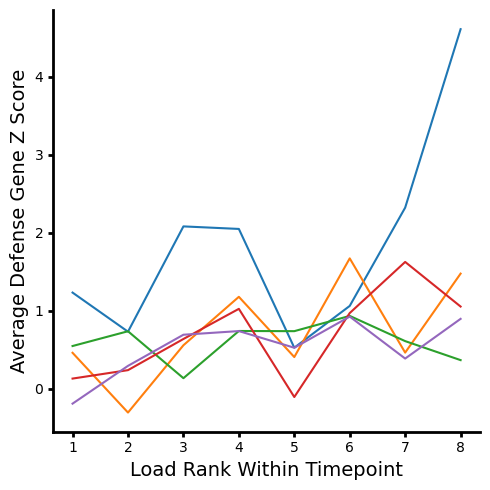

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.lineplot(
    data=plotting_df[
        plotting_df["timepoint"].isin(["t01", "t02", "t03", "t04", "t05"])
    ],
    x="Rank Within Timepoint",
    y="Summed Defense Z Score",
    hue="timepoint",
)
plt.xlabel("Load Rank Within Timepoint", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.get_legend().remove()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

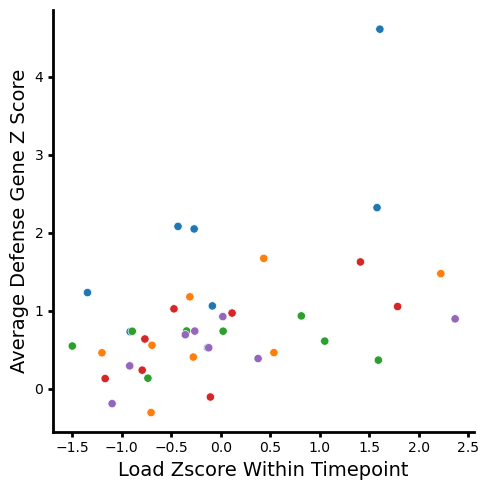

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    data=plotting_df[
        plotting_df["timepoint"].isin(["t01", "t02", "t03", "t04", "t05"])
    ],
    x="Zscore within Timepoint",
    y="Summed Defense Z Score",
    hue="timepoint",
)
plt.xlabel("Load Zscore Within Timepoint", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.get_legend().remove()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

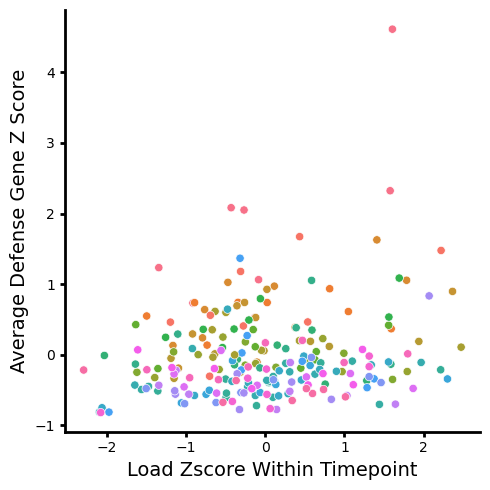

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    data=plotting_df[plotting_df["Experiment Type"] == "Long Term"],
    x="Zscore within Timepoint",
    y="Summed Defense Z Score",
    hue="timepoint",
)
plt.xlabel("Load Zscore Within Timepoint", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.get_legend().remove()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

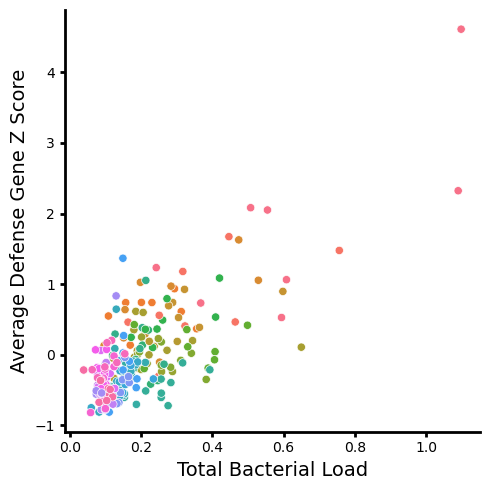

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    data=plotting_df[plotting_df["Experiment Type"] == "Long Term"],
    x="ham16s",
    y="Summed Defense Z Score",
    hue="timepoint",
)
plt.xlabel("Total Bacterial Load", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.get_legend().remove()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

## Genus abundance vs defense score

In [11]:
abund_cols = [col for col in plotting_df.columns if col.endswith("_Abund")]
correlation_df = pd.DataFrame(
    {
        "Column": abund_cols,
        "Correlation_with_Summed_Defense_Z_Score": [
            plotting_df["Summed Defense Z Score"].corr(plotting_df[col])
            for col in abund_cols
        ],
    }
).sort_values("Correlation_with_Summed_Defense_Z_Score", ascending=False)

correlation_df.head(20)

,Column,Correlation_with_Summed_Defense_Z_Score
52,g__Belnapia_Abund,0.360378
205,g__Rhizobium_Abund,0.340827
34,g__Alsobacter_Abund,0.325695
146,g__Microbacterium_Abund,0.308536
143,g__Methylobacterium_Abund,0.291650
76,g__Curtobacterium_Abund,0.272419
92,g__Friedmanniella_Abund,0.266040
262,o__UBA5066 Order_Abund,0.265214
157,g__Neorhizobium_Abund,0.259742
86,g__Duganella_Abund,0.257220


Top 3 taxa: ['g__Belnapia', 'g__Rhizobium', 'g__Microbacterium']
Bottom 3 taxa: ['f__Burkholderiaceae_A_595421 Family', 'g__Limnohabitans', 'g__Kordiimonas']


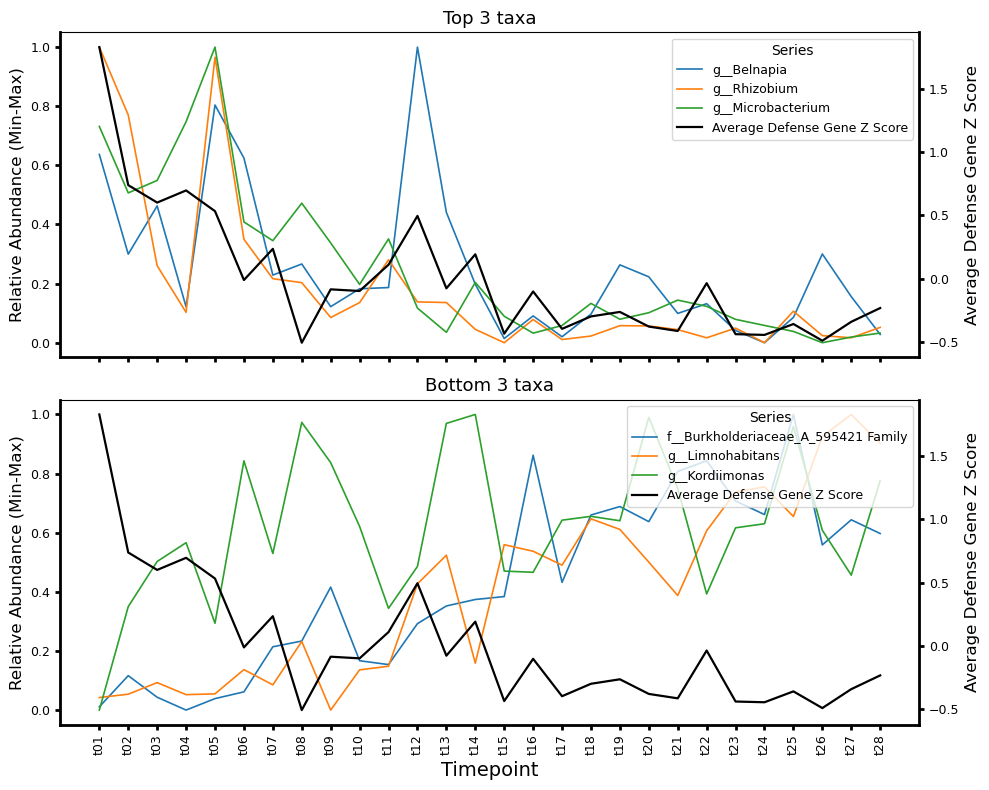

In [12]:
from matplotlib.lines import Line2D

# Drop NaN correlations and exclude selected taxa
excluded_taxa = ["Marihabitans", "Alsobacter"]
correlation_df_filtered = correlation_df.dropna(
    subset=["Correlation_with_Summed_Defense_Z_Score"]
)
excluded_pattern = "|".join(excluded_taxa)
correlation_df_filtered = correlation_df_filtered[
    ~correlation_df_filtered["Column"].str.contains(
        excluded_pattern, case=False, na=False
    )
]

# Select top 3 and bottom 3 taxa by correlation
top_3 = correlation_df_filtered.head(3)["Column"].tolist()
bottom_3 = correlation_df_filtered.tail(3)["Column"].tolist()
selected_abundance_cols = top_3 + bottom_3

# Prepare timepoint-level dataframe
line_df = plotting_df[
    ["timepoint", "Summed Defense Z Score"] + selected_abundance_cols
].copy()
line_df = line_df.groupby("timepoint", as_index=False).mean(numeric_only=True)
line_df["timepoint"] = pd.Categorical(
    line_df["timepoint"],
    categories=sorted(line_df["timepoint"].unique()),
    ordered=True,
)
line_df = line_df.sort_values("timepoint")

# Long-form abundance dataframe and min-max normalization by taxa
abundance_df = line_df.melt(
    id_vars="timepoint",
    value_vars=selected_abundance_cols,
    var_name="Series",
    value_name="Relative Abundance",
)
abundance_df["Series"] = abundance_df["Series"].str.replace("_Abund", "", regex=False)
abundance_df["Relative Abundance (Min-Max)"] = abundance_df.groupby("Series")[
    "Relative Abundance"
].transform(
    lambda values: (
        (values - values.min()) / (values.max() - values.min())
        if values.max() != values.min()
        else 0.0
    )
)

top_names = [col.replace("_Abund", "") for col in top_3]
bottom_names = [col.replace("_Abund", "") for col in bottom_3]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.patch.set_facecolor("white")

for ax_left, taxa_names, title in [
    (axes[0], top_names, "Top 3 taxa"),
    (axes[1], bottom_names, "Bottom 3 taxa"),
]:
    subset_df = abundance_df[abundance_df["Series"].isin(taxa_names)]

    # Left axis: normalized relative abundance
    sns.lineplot(
        data=subset_df,
        x="timepoint",
        y="Relative Abundance (Min-Max)",
        hue="Series",
        linewidth=1.2,
        ax=ax_left,
    )
    ax_left.set_ylabel("Relative Abundance (Min-Max)", fontsize=12)
    ax_left.set_title(title, fontsize=13)
    ax_left.spines["bottom"].set_color("black")
    ax_left.spines["bottom"].set_linewidth(2)
    ax_left.spines["left"].set_color("black")
    ax_left.spines["left"].set_linewidth(2)
    ax_left.tick_params(axis="both", width=2, labelsize=9)

    # Right axis: summed defense z score
    ax_right = ax_left.twinx()
    sns.lineplot(
        data=line_df,
        x="timepoint",
        y="Summed Defense Z Score",
        color="black",
        linewidth=1.6,
        label="_nolegend_",
        ax=ax_right,
    )
    ax_right.set_ylabel("Average Defense Gene Z Score", fontsize=12)
    ax_right.spines["right"].set_color("black")
    ax_right.spines["right"].set_linewidth(2)
    ax_right.tick_params(axis="y", width=2, labelsize=9)

    # Legend with a single summed defense entry
    handles_left, labels_left = ax_left.get_legend_handles_labels()
    filtered_pairs = [
        (handle, label)
        for handle, label in zip(handles_left, labels_left)
        if label != "Series"
    ]
    left_handles = [handle for handle, _ in filtered_pairs]
    left_labels = [label for _, label in filtered_pairs]
    defense_handle = Line2D([0], [0], color="black", linewidth=1.6)
    ax_left.legend(
        left_handles + [defense_handle],
        left_labels + ["Average Defense Gene Z Score"],
        title="Series",
        loc="upper right",
        fontsize=9,
    )

    sns.despine(ax=ax_left, right=False)

axes[1].set_xlabel("Timepoint", fontsize=14)
axes[1].tick_params(axis="x", rotation=90)
plt.tight_layout()

print("Top 3 taxa:", top_names)
print("Bottom 3 taxa:", bottom_names)

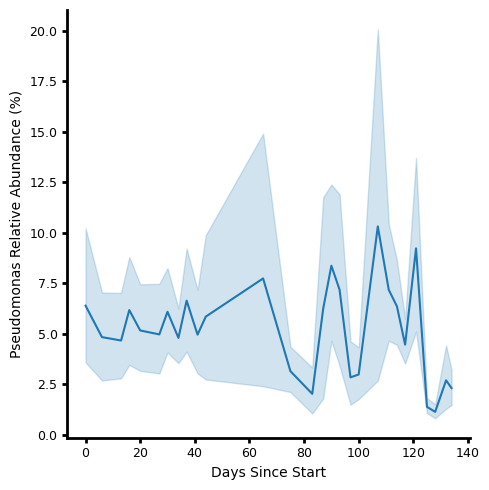

In [13]:
# Original plotted Pseudomonas_B_650453; the recalled table merges the
# Pseudomonas sub-genera into a single g__Pseudomonas
target_genus = "g__Pseudomonas"
target_genus_plot_df = genus_sum_w_tp.loc[
    genus_sum_w_tp["Genus"] == target_genus, ["sampID", "Abundance"]
]
target_genus_plot_df = target_genus_plot_df.merge(
    long_term_metadata[["sampID", "daysincestart"]],
    on="sampID",
    how="left",
).dropna(subset=["daysincestart"])

fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
fig.patch.set_facecolor("white")
ax = sns.lineplot(
    data=target_genus_plot_df.sort_values("daysincestart"),
    x="daysincestart",
    y="Abundance",
    errorbar=("ci", 95),
    color="#1f77b4",
)
plt.ylabel("Pseudomonas Relative Abundance (%)", fontsize=10)
plt.xlabel("Days Since Start", fontsize=10)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

In [14]:
correlation_df_filtered.head(50)

,Column,Correlation_with_Summed_Defense_Z_Score
52,g__Belnapia_Abund,0.360378
205,g__Rhizobium_Abund,0.340827
146,g__Microbacterium_Abund,0.308536
143,g__Methylobacterium_Abund,0.291650
76,g__Curtobacterium_Abund,0.272419
92,g__Friedmanniella_Abund,0.266040
262,o__UBA5066 Order_Abund,0.265214
157,g__Neorhizobium_Abund,0.259742
86,g__Duganella_Abund,0.257220
221,g__Silvanigrella_Abund,0.242714


In [15]:
# plotting_df.rename(
#     columns={
#         "timepoint": "Timepoint",
#         "Summed Defense Z Score": "Average Defense Z Score",
#     }
# ).to_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/For_talk/full_long_term_metadata_plates_1_to_5_recalled_genera.csv",
#     index=False,
# )
# line_df[["timepoint", "Summed Defense Z Score"]].rename(
#     columns={
#         "timepoint": "Timepoint",
#         "Summed Defense Z Score": "Average Defense Z Score, Averaged Across Samples in Timepoint",
#     }
# ).to_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/For_talk/timepoint_summed_defense_z_scores_plates_1_to_5.csv",
#     index=False,
# )
# abundance_df.rename(
#     columns={
#         "Series": "Genus",
#         "Relative Abundance (Min-Max)": "Relative Abundance (Min-Max Normalized)",
#     }
# ).to_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/For_talk/top_and_bottom_3_taxa_abundance_corr_recalled_genera.csv",
#     index=False,
# )

Number of samples in histogram: 222


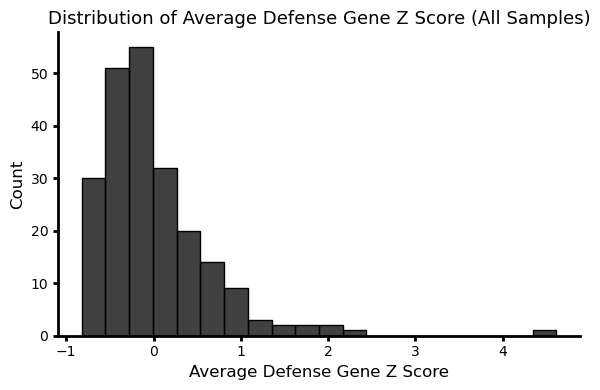

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor("white")

hist_data = plotting_df["Summed Defense Z Score"].dropna()
sns.histplot(hist_data, bins=20, color="black", ax=ax)

plt.xlabel("Average Defense Gene Z Score", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Average Defense Gene Z Score (All Samples)", fontsize=13)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2, labelsize=10)
plt.tight_layout()

print(f"Number of samples in histogram: {hist_data.shape[0]}")

## Rare genera total abundance

Rare genera are those present in fewer than 10% of seasonal plant samples, the same definition as `core_and_rare_species_definitions_and_temporal_patterns.ipynb`.

Rare genera: 145


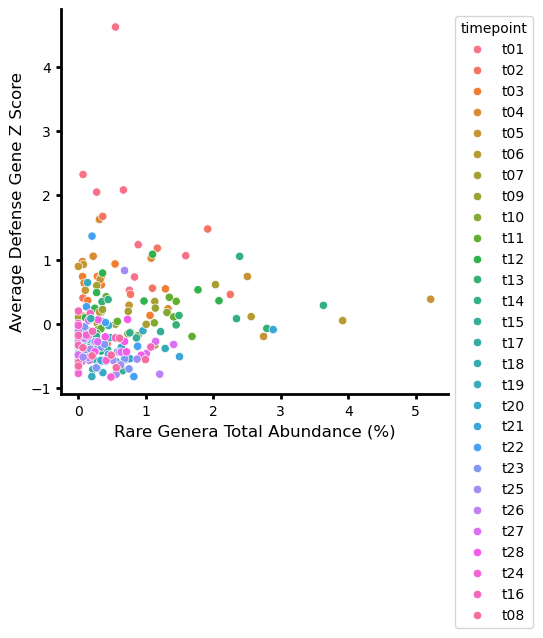

In [17]:
genus_prevalence = (genus_abundance_matrix > 0).mean()
rare_genera = genus_prevalence.index[genus_prevalence < 0.10]
print(f"Rare genera: {len(rare_genera)}")

plotting_df_added_info = plotting_df.assign(
    rare_genera_total_abund=plotting_df["sampID"].map(
        genus_abundance_matrix[rare_genera].sum(axis=1)
    )
)

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
sns.scatterplot(
    data=plotting_df_added_info,
    x="rare_genera_total_abund",
    y="Summed Defense Z Score",
    hue="timepoint",
    ax=ax,
)
plt.xlabel("Rare Genera Total Abundance (%)", fontsize=12)
plt.ylabel("Average Defense Gene Z Score", fontsize=12)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2, labelsize=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

## Early (before t14) vs late (t14 onward) genus correlations

In [18]:
def genus_correlations(df, minimum_present_samples=7):
    """Correlation of each genus with the defense score, using only the samples
    where that genus is present."""
    rows = []
    for col in [c for c in df.columns if c.endswith("_Abund")]:
        present_mask = df[col].fillna(0) > 0
        n_present_samples = int(present_mask.sum())
        if n_present_samples < minimum_present_samples:
            continue
        filtered_df = df.loc[present_mask, ["Summed Defense Z Score", col]].dropna()
        rows.append(
            {
                "Column": col,
                "Present_Sample_Count": n_present_samples,
                "Correlation_with_Summed_Defense_Z_Score": filtered_df[
                    "Summed Defense Z Score"
                ].corr(filtered_df[col]),
            }
        )
    return pd.DataFrame(rows).sort_values(
        "Correlation_with_Summed_Defense_Z_Score", ascending=False
    )


timepoint_number = plotting_df["timepoint"].str.extract(r"(\d+)")[0].astype(int)
correlation_df_t14_onward = genus_correlations(plotting_df.loc[timepoint_number >= 14])
correlation_df_pre_t14 = genus_correlations(plotting_df.loc[timepoint_number < 14])
correlation_df_t14_onward

,Column,Present_Sample_Count,Correlation_with_Summed_Defense_Z_Score
18,g__Arthrobacter_Abund,9,0.912984
1,f__Bryobacteraceae Family_Abund,10,0.824094
65,g__Leifsonia_Abund,7,0.724289
45,g__GWA1-52-35_Abund,15,0.706374
91,g__Pedosphaera_Abund,7,0.678967
...,...,...,...
21,g__Bdellovibrio_Abund,19,-0.283051
119,g__Terracoccus_Abund,13,-0.293744
41,g__Enterovirga_Abund,22,-0.348408
122,g__UBA4416_Abund,7,-0.442181


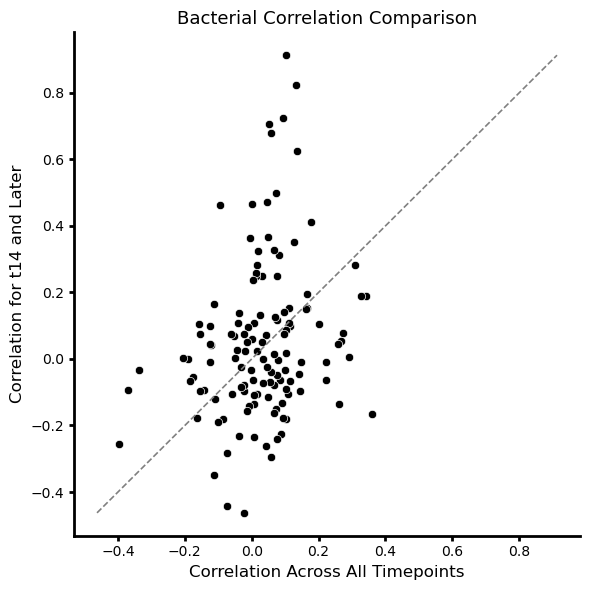

Correlation between the two: 0.228


,Column,Correlation_with_Summed_Defense_Z_Score_All_Timepoints,Correlation_with_Summed_Defense_Z_Score_T14_Onward,Present_Sample_Count
0,g__Belnapia_Abund,0.360378,-0.164914,31
1,g__Rhizobium_Abund,0.340827,0.189289,26
2,g__Alsobacter_Abund,0.325695,0.187715,48
3,g__Microbacterium_Abund,0.308536,0.281391,116
4,g__Methylobacterium_Abund,0.291650,0.006464,119
...,...,...,...,...
123,g__Polaromonas_Abund,-0.189592,0.000147,33
124,g__Tibeticola_Abund,-0.206116,0.004059,100
125,f__Burkholderiaceae_A_595421 Family_Abund,-0.337971,-0.032214,119
126,g__Limnohabitans_Abund,-0.368630,-0.093826,119


In [19]:
def plot_correlation_comparison(period_df, suffix, ylabel, title):
    comparison_df = correlation_df[
        ["Column", "Correlation_with_Summed_Defense_Z_Score"]
    ].merge(
        period_df[
            ["Column", "Correlation_with_Summed_Defense_Z_Score", "Present_Sample_Count"]
        ],
        on="Column",
        suffixes=("_All_Timepoints", suffix),
        how="inner",
    )
    x_col = "Correlation_with_Summed_Defense_Z_Score_All_Timepoints"
    y_col = f"Correlation_with_Summed_Defense_Z_Score{suffix}"
    comparison_df = comparison_df.dropna(subset=[x_col, y_col])

    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor("white")
    sns.scatterplot(data=comparison_df, x=x_col, y=y_col, color="black", ax=ax)
    min_corr = comparison_df[[x_col, y_col]].min().min()
    max_corr = comparison_df[[x_col, y_col]].max().max()
    ax.plot(
        [min_corr, max_corr],
        [min_corr, max_corr],
        linestyle="dashed",
        color="gray",
        linewidth=1.2,
    )
    plt.xlabel("Correlation Across All Timepoints", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=13)
    sns.despine()
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(2)
    ax.tick_params(axis="both", width=2, labelsize=10)
    plt.tight_layout()
    plt.show()

    print(f"Correlation between the two: {comparison_df[x_col].corr(comparison_df[y_col]):.3f}")
    return comparison_df


correlation_comparison_df = plot_correlation_comparison(
    correlation_df_t14_onward,
    "_T14_Onward",
    "Correlation for t14 and Later",
    "Bacterial Correlation Comparison",
)
correlation_comparison_df

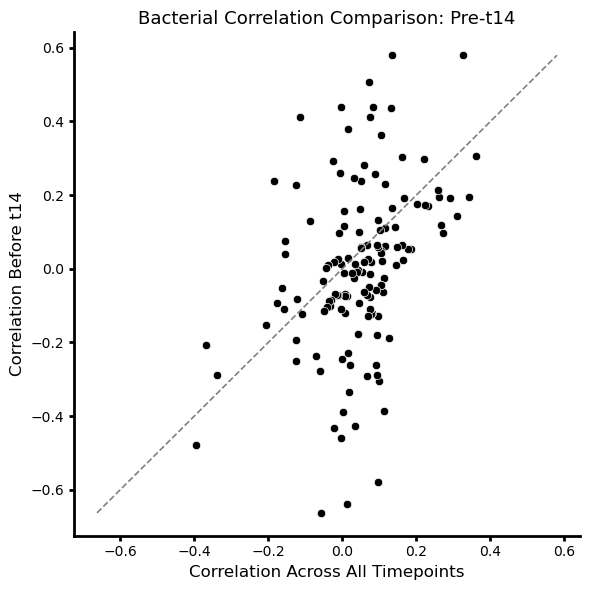

Correlation between the two: 0.383


,Column,Correlation_with_Summed_Defense_Z_Score_All_Timepoints,Correlation_with_Summed_Defense_Z_Score_Pre_T14,Present_Sample_Count
0,g__Belnapia_Abund,0.360378,0.307443,53
1,g__Rhizobium_Abund,0.340827,0.195944,51
2,g__Alsobacter_Abund,0.325695,0.579916,44
3,g__Microbacterium_Abund,0.308536,0.144454,102
4,g__Methylobacterium_Abund,0.291650,0.191238,103
...,...,...,...,...
134,g__Chioneia_Abund,-0.185045,0.237401,7
135,g__Tibeticola_Abund,-0.206116,-0.151471,48
136,f__Burkholderiaceae_A_595421 Family_Abund,-0.337971,-0.289361,101
137,g__Limnohabitans_Abund,-0.368630,-0.205934,102


In [20]:
correlation_comparison_pre_t14_df = plot_correlation_comparison(
    correlation_df_pre_t14,
    "_Pre_T14",
    "Correlation Before t14",
    "Bacterial Correlation Comparison: Pre-t14",
)
correlation_comparison_pre_t14_df

## Defense score spread per timepoint

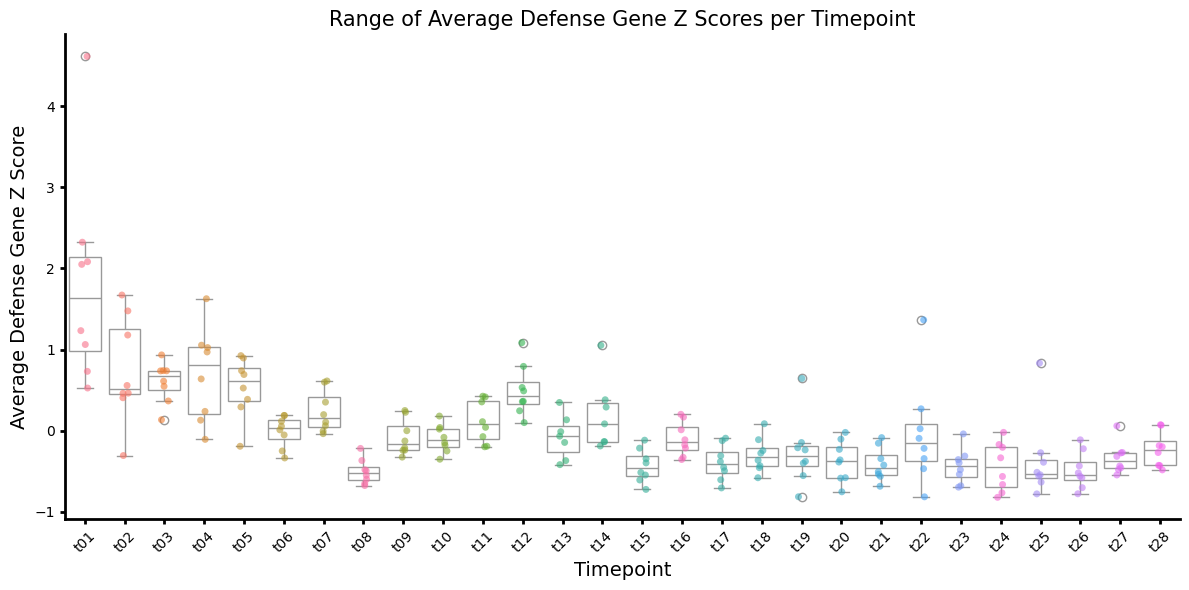

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("white")

sorted_timepoints = sorted(plotting_df["timepoint"].unique())

sns.boxplot(
    data=plotting_df,
    x="timepoint",
    y="Summed Defense Z Score",
    order=sorted_timepoints,
    ax=ax,
    color="white",
)
sns.stripplot(
    data=plotting_df,
    x="timepoint",
    y="Summed Defense Z Score",
    order=sorted_timepoints,
    alpha=0.6,
    ax=ax,
    hue="timepoint",
    legend=False,
)

plt.xlabel("Timepoint", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
plt.title("Range of Average Defense Gene Z Scores per Timepoint", fontsize=15)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2, labelsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

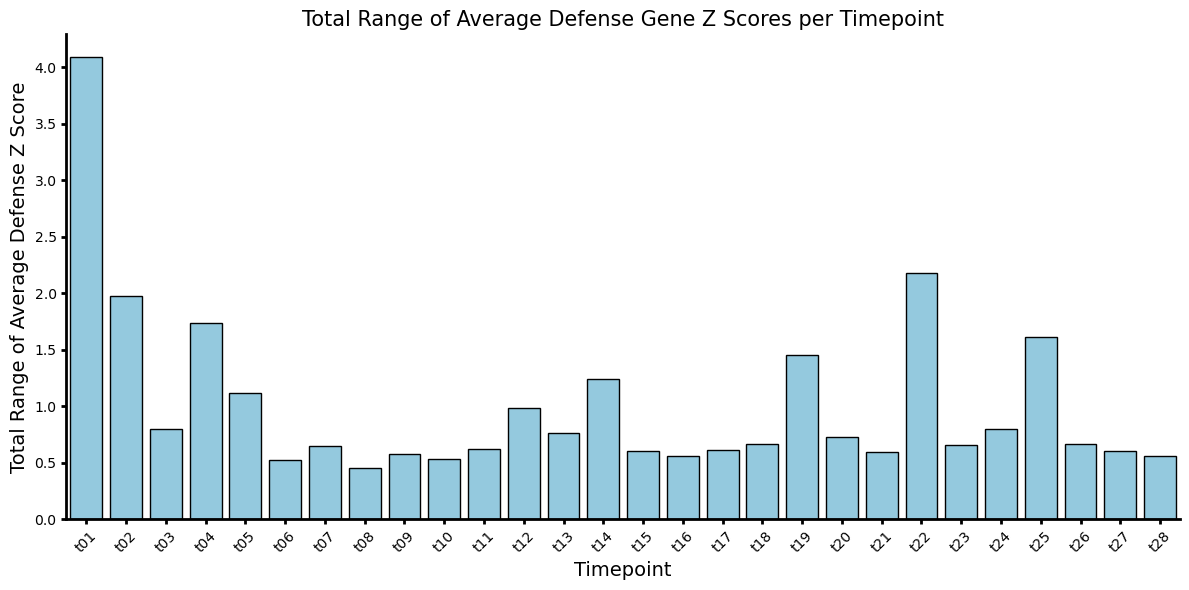

In [22]:
# Calculate the total range (max - min) within each timepoint
range_df = (
    plotting_df.groupby("timepoint")["Summed Defense Z Score"]
    .agg(lambda x: x.max() - x.min())
    .reset_index(name="Total Range")
)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("white")
sns.barplot(
    data=range_df,
    x="timepoint",
    y="Total Range",
    order=sorted(range_df["timepoint"].unique()),
    ax=ax,
    color="skyblue",
    edgecolor="black",
)
plt.xlabel("Timepoint", fontsize=14)
plt.ylabel("Total Range of Average Defense Z Score", fontsize=14)
plt.title("Total Range of Average Defense Gene Z Scores per Timepoint", fontsize=15)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2, labelsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()